# Expert persona eval analysis

## 🔍 Overview

#### Introduction

This notebook analyses the results of an experiment comparing LLM performance under two conditions: a control condition with no persona and an experimental condition with an expert persona. Each is tested using the gemini-2.5-flash-lite model with a temperature of 0 (meaning less randomness) on the same set of of 500 randomly selected questions from the [MMLU-Pro dataset](https://huggingface.co/datasets/TIGER-Lab/MMLU-Pro). MMLU-Pro is a dataset containing 12,032 test questions with 10 multiple choice options designed to test reasoning. 

The notebook covers:

- Data preparation — transforming the raw results and accounting for parse failures.
- Descriptive statistics — overall and per-category pass rates for each condition.
- Inferential statistics — using bootstrapping to estimate the uncertainty around the observed effect size and the Exact McNemar's test to assess statistical significance.

#### Results & weaknesses

A raw difference in pass rates between conditions is not on its own strong evidence of a real effect. Despite observing a 1 percentage point increase in accuracy for the expert persona, the inferential statistical techniques used suggest that this is very likely due to chance. This is because bootstrapping (with 10,000 iterations) gives us a 95% confidence interval with a lower bound less than 0 (meaning it is plausible that an expert persona has no effect) and the Exact McNemar's test results in a p-value of 0.55 (well above the 0.05 traditionally used as a threshold for statistical significance). 

The weaknesses of this experiment include that fact that it used the MMLU-pro dataset, a well known public dataset that could have seeped into the model's training data and led to data contamination (i.e. when a model remembers an answer rather than using reasoning to work it out). The experiment also only uses 500 unique questions, conducts a single run on each question, assigns a relatively simple expert persona with little detail and tests on only a single model, limiting its wider generalisability.
<br><br>

## 🛢️ Data preparation

#### Prompt versions 

Multiple prompt versions have been used, but this notebook will only analyse data from the current prompt version.

#### Parse failure handling

The program used to obtain the results does not save questions that exhaust all of the LLM retry attempts but does for those that produce a response from the LLM that can't be parsed. The program has the option to retry previous parse failures when doing new runs, meaning total parse failures and unique parse failures may be different. Also, sometimes a parse failure occurs for a question under one conditon but not another. To keep things fair, both questions are removed in this case.

In [1]:
import pandas as pd
from IPython.display import Markdown, display, Math

df = pd.read_json('results.jsonl', lines=True)

# prompt versions
current_prompt_version = 'question_v2'
current_prompt_df = df[df['prompt']==current_prompt_version]

display(Math(rf'\begin{{array}}{{l}} \\ \\ \mathbf{{Dataset\ size}} \\ \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} \text{{Total rows (all prompt versions)}} = {len(df)} \\ \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} \text{{Total rows (current prompt version)}} = {len(current_prompt_df)} \end{{array}}'))

display(Markdown('> *Note: from here all metrics refer to data for the current prompt only.*'))


# parse failures
parse_failures = len(current_prompt_df[current_prompt_df['result']=='parse_failure'])
unique_parse_failures = len(current_prompt_df[current_prompt_df['result']=='parse_failure']['question'].unique())
parse_failure_questions = current_prompt_df[current_prompt_df['result']=='parse_failure']['question'].unique()
filtered_df = current_prompt_df[~current_prompt_df['question'].isin(parse_failure_questions)]
filtered_df = filtered_df[filtered_df['question'].duplicated(keep=False)]
filtered_df.reset_index(inplace=True)
usable_rows = len(filtered_df)
usable_rows_per_condition = len(filtered_df[filtered_df['is_expert']==True])

display(Math(rf'\begin{{array}}{{l}} \\ \\ \mathbf{{Parse\ summary}} \\ \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} \text{{Total parse failures}} = {parse_failures} \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} \text{{Unique parse failures}} = {unique_parse_failures} \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} \text{{Rows removed due to parse failures}} = {len(current_prompt_df) - usable_rows} \\ \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} \text{{Total usable rows}} = {usable_rows} \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} \text{{Usable rows per condition}} = {usable_rows_per_condition} \end{{array}}'))

display(Math(rf'\begin{{array}}{{l}} \\ \\ \mathbf{{Example\ data}} \\ \\ \end{{array}}'))
display(filtered_df.head())

print('\n')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

> *Note: from here all metrics refer to data for the current prompt only.*

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,index,result,category,is_expert,question,correct_answer,llm_answer,asked_at,prompt,model
0,4,fail,math,True,Use divergence therem to evaluate $\iint_S \ve...,I,(B),2026-06-30 16:57:26+00:00,question_v2,gemini-2.5-flash-lite
1,5,pass,law,True,"A buyer contracted in writing to purchase 1,00...",A,(A),2026-06-30 16:57:41+00:00,question_v2,gemini-2.5-flash-lite
2,6,fail,business,True,"Suppose there are 8,000 hours in a year (actua...",G,(C),2026-06-30 16:59:29+00:00,question_v2,gemini-2.5-flash-lite
3,7,pass,computer science,True,"Let a undirected graph G with edges E = {<0,1>...",H,(H),2026-06-30 16:59:45+00:00,question_v2,gemini-2.5-flash-lite
4,8,pass,math,True,What is the value of p in 24 = 2p?,H,(H),2026-06-30 17:00:01+00:00,question_v2,gemini-2.5-flash-lite


## 📊 Descriptive statistics

#### Overall statistics

The results are summarized numerically using overall pass rates and the difference between them (expert persona minus control persona accuracy) for each condition in percentages. 

#### Pass rates by category 

The results are also visualized as a plot of pass rates for each condition by category in percentages.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

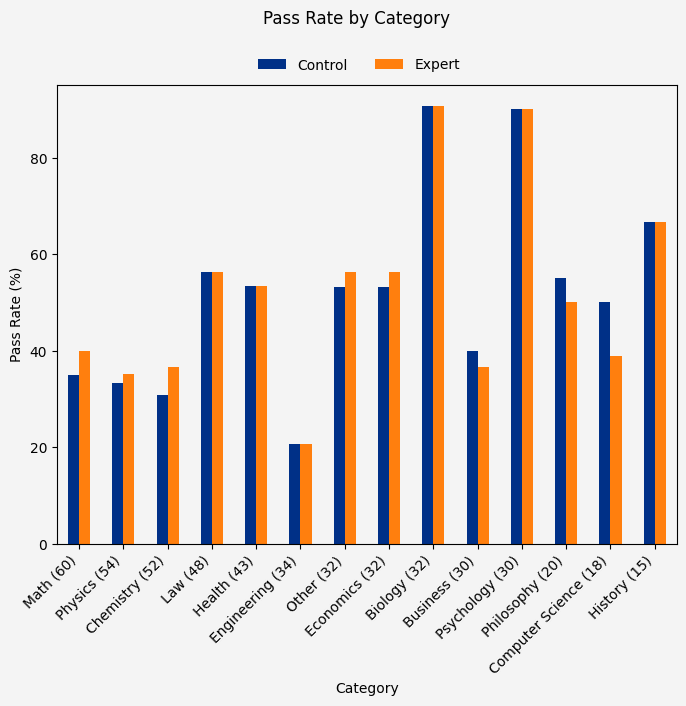

In [2]:
import matplotlib.pyplot as plt


background_color = '#f4f4f4'


# overall pass rate
control_pass_rate = round(float((filtered_df[filtered_df['is_expert']==False]['result']=='pass').mean()) * 100, 2)
expert_pass_rate = round(float((filtered_df[filtered_df['is_expert']==True]['result']=='pass').mean()) * 100, 2)

display(Math(rf'\begin{{array}}{{l}} \\ \\ \mathbf{{Pass\ rates}} \\ \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} \text{{Control pass rate}} = {control_pass_rate}\% \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} \text{{Expert pass rate}} = {expert_pass_rate}\% \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} \text{{Difference}} = {expert_pass_rate - control_pass_rate}\% \\ \\ \end{{array}}'))


# pass rate by category vizz
category_counts = (
    filtered_df.groupby('category')['question']
    .nunique()
)

pass_rate = (
    (filtered_df['result'] == 'pass')
    .groupby([filtered_df['category'], filtered_df['is_expert']])
    .mean()
    * 100
)

plot_df = pass_rate.unstack()

plot_df = plot_df.rename(columns={False: 'Control', True: 'Expert'})

ordered_categories = category_counts.sort_values(ascending=False).index
plot_df = plot_df.loc[ordered_categories]

formatted_names = {
    cat: cat.replace('_', ' ').replace('-', ' ').title()
    for cat in plot_df.index
}

plot_df.index = [
    f'{formatted_names[cat]} ({int(category_counts[cat])})'
    for cat in plot_df.index
]

fig, ax = plt.subplots(figsize=(8, 6))

fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)  

plot_df.plot(kind='bar', ax=ax, color=['#003087', '#FF7F0E'])

ax.set_ylabel('Pass Rate (%)')
ax.set_xlabel('Category')

fig.suptitle('Pass Rate by Category', y=1)

ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.4875, 1),
    ncol=len(plot_df.columns),
    frameon=False
)

plt.xticks(rotation=45, ha='right')

plt.subplots_adjust(top=0.875)

fig.savefig(
    'assets/pass_rate_by_category.png',
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print()

## 🎲 Inferential statistics

#### Bootstrapping

This resampling method was chosen because the experiment was only run once using a limited number of questions. Bootstrapping helps us estimate the uncertainty around our observed effect size by repeatedly resampling the data (with replacement) and recomputing the evaluation metric (in this case the expert persona pass rate minus the control pass rate). The resulting variation is treated as akin to that expected if the experiment were rerun on new data. If this variation is low, we can be more confident in the magnitude of our result. The variation is measured in two ways: the standard error (a measure of evaluation metric variability across resamples) and 95% confidence interval (a range containing the middle 95% of evaluaton metric values computed).

#### Exact McNemar’s test

This statistical significance test was selected because the data is paired (each question is answered under control and expert persona conditions), the results are binary (pass or fail), the data can be arranged in a 2×2 table and the disagreement counts (cases where a question passes under one condition but fails under the other) are relatively low (making the standard McNemar's test implementation less reliable). McNemar's test uses these disagreement counts to estimate the probability that our observed difference could have occurred by chance alone (p-value). If the expert persona truly has no effect, the disagreement counts would be expected to happen roughly equally in both directions with large deviations from this less likely. 
<br><br>

### 1) Bootstrapping implementation

#### 1.1) Standard error

$$SE_{\text{boot}} = \sqrt{\frac{1}{B-1}\sum_{b=1}^{B}\left(M^{(b)}-\bar{M}\right)^2}$$

**Where:**

$M$ = the evaluation metric (the expert persona pass rate minus the control pass rate).

$B$ = the number of bootstrap resamples drawn.

$b$ = a stand-in number representing which resample we're currently on.

$M^{(b)}$ = the value of $M$ calculated on the $b$-th bootstrap resample.

> *Note: a bootstrap resample is created by randomly drawing observations from the original dataset with replacement. This means some values may appear multiple times in a given resample and others not at all. Each time we recompute $M$ on the new resample, giving us $B$ different evaluation metric values: $M^{(1)}, M^{(2)}, \dots, M^{(B)}$.*

$\bar{M}$ = the average of all $B$ evaluation metric values.

$\left(M^{(b)} - \bar{M}\right)^2$ = how far a single resample's evaluation metric value strays from the average of all the resampled values squared.

> *Note: squaring is used here so that negative and positive differences don't cancel each other out. It also gives greater weight to larger deviations.*

$\sum_{b=1}^{B}$ = adds up the squared deviations across all $B$ resamples.

$\frac{1}{B-1}$ = turns the sum of squared deviations into an average, which gives us the *variance* of the bootstrapped metric values — a measure of how spread out they are.

> *Note: you might expect to divide by $B$ to get a plain average, but we divide by $B-1$ instead. This is because $\bar{M}$ is calculated from the limited data we actually collected. If we had infinite data, the true average would likely be a bit higher or a bit lower. Either way, since we're squaring the deviations, the direction doesn't matter: any mismatch between $\bar{M}$ and the true average makes our variance estimate a little too small. Dividing by $B-1$ instead of $B$ increases the estimated variance just enough to correct for this bias.*


> *At this point, $\frac{1}{B-1}\sum_{b=1}^{B}\left(M^{(b)} - \bar{M}\right)^2$ gives us a variance. This tells us how spread out the resampled metric values are, but it's in squared units (i.e. because $M$ is a percentage, the variance is in "percentage points squared"), which isn't directly interpretable on the original scale of $M$.*

$\sqrt{\phantom{x}}$ = converts the variance back into the original units of $M$ by undoing the earlier squaring step.

$SE_{\text{boot}}$ = the final bootstrapped standard error. It estimates how much our metric $M$ would be expected to vary from sample to sample.
> *Note: A larger value means more variation and greater uncertainty in the result.*

<br>

#### 1.2) 95% confidence interval (percentile method)  

$$CI_{95\%} = \left[\, M_{(0.025)},\ M_{(0.975)} \,\right]$$  

**Where:**  

$M_{(0.025)}$ = the value at the 2.5th percentile of the sorted bootstrapped values — i.e. only 2.5% of resamples produced a value this low or lower.  

$M_{(0.975)}$ = the value at the 97.5th percentile of the sorted bootstrapped values — i.e. only 2.5% of resamples produced a value this high or higher.
> *Note: "percentile" here means sorting all $B$ bootstrapped evaluation metric values from smallest to largest and reading off the value at a given position based on percentage. Together, these two cutoffs trim off the most extreme 2.5% of resampled values on each end, so the range between them spans the middle 95%.*

$CI_{95\%}$ = the final interval — a range that's likely to contain the true value of $M$ based on the spread of our bootstrapped evaluation metric values.
> *Note: a larger range means more variation and greater uncertainty in the result. Also, if the lower end of this range falls below 0, it severely limits our confidence in the efficacy of using an expert persona for LLMs because a difference of 0 or less remains plausible.*

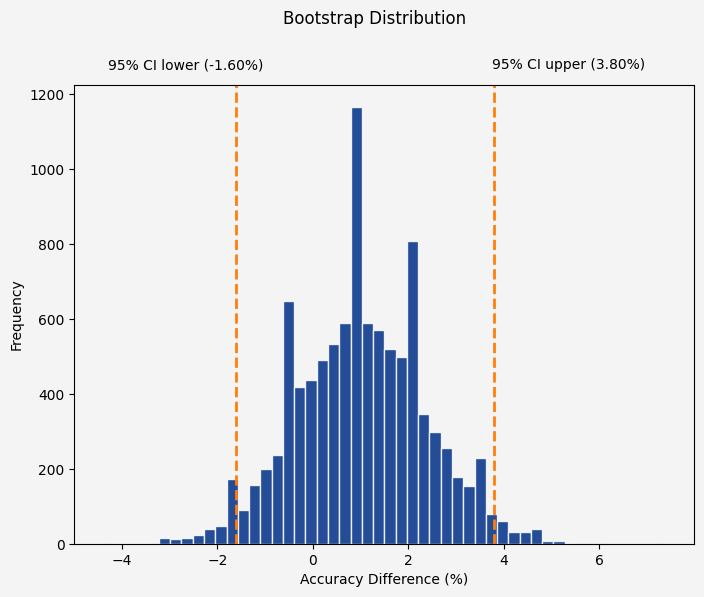

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...



...




<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
import numpy as np


verbose = True
truncate_at = 5


# bootstrap calculation
paired = filtered_df.pivot(
    index='question',
    columns='is_expert',
    values='result'
)

paired.columns = ['control', 'expert']

paired = paired.reset_index()

paired['control'] = paired['control'] == 'pass'
paired["expert"] = paired['expert'] == 'pass'

rng = np.random.default_rng(seed=2026)

n = len(paired)
n_bootstrap = 10000

control = np.empty(n_bootstrap)
expert = np.empty(n_bootstrap)
results = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    
    indices = rng.choice(n, size=n, replace=True)
    sample = paired.iloc[indices]

    control_accuracy = sample['control'].mean()
    expert_accuracy = sample['expert'].mean()

    control[i], expert[i] = control_accuracy, expert_accuracy
    
    difference = expert_accuracy - control_accuracy

    results[i] = difference * 100

M_hat = results.mean()
ci = np.percentile(results, [2.5, 97.5])


print()


# bootstrap distribution vizz
fig, ax = plt.subplots(figsize=(8, 6))

fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)

ax.hist(
    results,
    bins=50,
    color='#003087',
    edgecolor='white',
    alpha=0.85
)

ax.axvline(
    ci[0],
    color='#FF7F0E',
    linestyle='--',
    linewidth=2,
    label=f'95% CI lower ({ci[0]:.2f}%)'
)
ax.axvline(
    ci[1],
    color='#FF7F0E',
    linestyle='--',
    linewidth=2,
    label=f'95% CI upper ({ci[1]:.2f}%)'
)

ax.set_ylabel('Frequency')
ax.set_xlabel('Accuracy Difference (%)')
fig.suptitle('Bootstrap Distribution', y=1)
ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.4875, 1),
    ncol=2,
    columnspacing=16.5,
    handlelength=0,
    handletextpad=0,
    frameon=False
)
plt.subplots_adjust(top=0.875)

fig.savefig(
    'assets/bootstrap_histogram.png',
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# show results
if verbose: 
    stop = len(results)
    
    if truncate_at is not None and isinstance(truncate_at, (int)):
        stop = min(truncate_at, len(results))

    for i, result in enumerate(results[:stop]):
        display(Math(rf'\begin{{array}}{{l}} \\ \\ \mathbf{{Resample\ {i+1}/{n_bootstrap}}} \\ \end{{array}}'))
        display(Math(rf'\begin{{array}}{{l}} \text{{Control accuracy}} = {control[i] * 100:.2f}\% \end{{array}}'))
        display(Math(rf'\begin{{array}}{{l}} \text{{Expert accuracy}} = {expert[i] * 100:.2f}\% \\ \end{{array}}'))
        display(Math(rf'\begin{{array}}{{l}} M^{{(b)}} = {result:.2f}\% \end{{array}}'))
    
    if stop < len(results):
        print("\n\n...\n\n")

display(Math(rf'\begin{{array}}{{l}} \mathbf{{Bootstrap\ results}} \\ \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} \bar{{M}} = {results.mean():.2f}\% \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} SE_{{\text{{boot}}}} = {results.std(ddof=1):.2f}\% \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} CI_{{95\%}} = [{ci[0]:.2f}\%,\; {ci[1]:.2f}\%] \\ \\ \\ \\ \end{{array}}'))

### 2) Exact McNemar's test implementation

$$p = 2 \times \sum_{i=0}^{\min(b,c)} \binom{b+c}{i} \left(0.5\right)^{b+c}$$

**Where:**

$b$ = the number of questions where the *first* condition (e.g., control) got it right and the *second* condition (expert-persona) got it wrong.

$c$ = the number of questions where the *second* condition (expert-persona) got it right and the *first* condition (control) got it wrong.

$b + c$ = the total number of disagreements.

$i$ = a stand-in number representing the number of disagreements that went in a specific direction.

> *Note: this is used as a part of a loop where the theoretical probability of observing a result at each value of $i$ is calculated (see more on how this is done below). The loop begins at 0 and stops at the smaller of the two disagreement counts, $\min(b,c)$. This upper limit is selected because it represents outcomes as unlikely as or more than what we observed (we would normally expect a 50/50 split between $b$ or $c$ if there were really no difference between the conditions). These probabilities are then summed to give us the overall probability of observing a result as extreme as ours or more by chance alone (p-value).*

$\binom{b+c}{i}$ = out of the total disagreements, how many different ways could we have arranged exactly $i$ of those questions to favor a certain condition. The more theoretical combinations that can produce a specific outcome, the more likely it is. For example, you are more likely to roll a 7 than a 12 when using two dice because multiple combinations result in a 7 and only one a 12.

$\left(0.5\right)^{b+c}$ = the probability of any *one single, specific* sequence for $b + c$ disagreements. If the persona truly had no effect, each disagreement would have a 50/50 chance of going either way, hence the 0.5 assumption. The term above, $\binom{b+c}{i}$, is multiplied by this term to calculate the likelihood of a specific result based on the total disagreements.

> *Note: even when there are many potential ways of arranging $i$ questions to favour a certain condition, there will also be an exponentially larger pool of total possible arrangements if the number of total disagreements ($b + c$) is high. Using $\left(0.5\right)^{b+c}$ takes this into account and keeps the final result a valid probability rather than an ever-inflating count.* 

$\sum_{i=0}^{\min(b,c)}$ = adds up the probabilities of every outcome *at least as imbalanced* as what we actually saw in our experiment. We need this because a p-value isn't just "how likely is my exact result" — it's an answer to the question of "how likely would we be to observe a result this extreme *or worse* by chance alone?"

$2 \times$ = makes the test two-sided. This means it determines the likelihood that an imbalance of this magnitude could have occured in *either* direction (i.e. for all we knew, the expert persona could have helped or hindered LLM performance).

$p$ = the final probability (p-value). A small $p$ (conventionally < 0.05) means the split between $b$ and $c$ is unlikely to be due to chance alone.

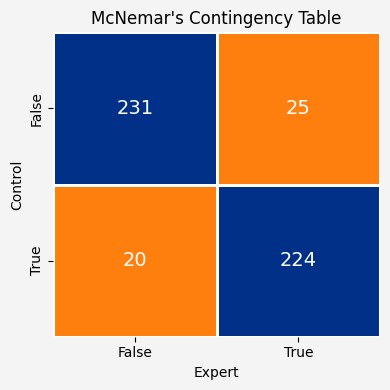

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...




...





<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
from matplotlib.colors import ListedColormap
import seaborn as sns


verbose = True
truncate_at = 5


# contingency table vizz
table = pd.crosstab(
    paired['control'],
    paired['expert']
)

cmap = ListedColormap([
    '#FF7F0E',
    '#003087'
])

print()

fig, ax = plt.subplots(figsize=(4, 4))

fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)

sns.heatmap(
    table,
    annot=True,
    fmt='d',
    cmap=cmap,
    cbar=False,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 14},
    ax=ax
)
ax.set_xlabel('Expert')
ax.set_ylabel('Control')
ax.set_title("McNemar's Contingency Table")
plt.tight_layout()

fig.savefig(
    'assets/mcnemar_table.png',
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# calculate and show results
b = table.iloc[0, 1]
c = table.iloc[1, 0]
n = b + c

def comb(n, i):
    if i > n:
        return 0

    i = min(i, n - i)
    result = 1
    
    for j in range(1, i + 1):
            
        result = result * (n - i + j) // j
    
    return result

x = min(b, c)
p_value = 0

for i in range(x + 1):
    term = comb(n, i) * (0.5**n)
    
    if i < truncate_at and verbose:
        display(Math(rf'\begin{{array}}{{l}} \\ \\ \mathbf{{i = {i}/{x}}} \\ \end{{array}}'))
        display(Math(rf'p = p + \tbinom{{b+c}}{{i}}(0.5)^{{b+c}} = {p_value} + {term}'))


        if i + 1 == truncate_at:
            print('\n\n\n...\n\n\n')
        
    p_value += term

if verbose:
    display(Math(rf'\begin{{array}}{{l}} \mathbf{{Two‐tailed\ test}} \\ \end{{array}}'))
    display(Math(rf'\begin{{array}}{{l}} p = 2 \times p = 2 \times {min(1, p_value)} \end{{array}}'))

p_value = min(p_value * 2, 1)

display(Math(rf'\begin{{array}}{{l}} \\ \mathbf{{P‐value}} \\ \end{{array}}'))
display(Math(rf'\begin{{array}}{{l}} {p_value} \\ \\ \end{{array}}'))